<a href="https://colab.research.google.com/github/ssdeniz65/phyton/blob/main/proje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


✅ Simülasyon tamamlandı: CTR aralığı 3–25
Epoch 0000 | Loss: 77.4286
Epoch 0100 | Loss: 58.6142
Epoch 0200 | Loss: 43.8170
Epoch 0300 | Loss: 28.3310
Epoch 0400 | Loss: 12.7963
Epoch 0500 | Loss: 0.1015
Epoch 0600 | Loss: -19.4719
Epoch 0700 | Loss: -40.2411
Epoch 0800 | Loss: -66.4948
Epoch 0900 | Loss: -102.6265

✅ MAE: 2.202 | RMSE: 2.607 | R²: 0.788
✅ Mean Total Uncertainty: 0.0032 (std 0.0007)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

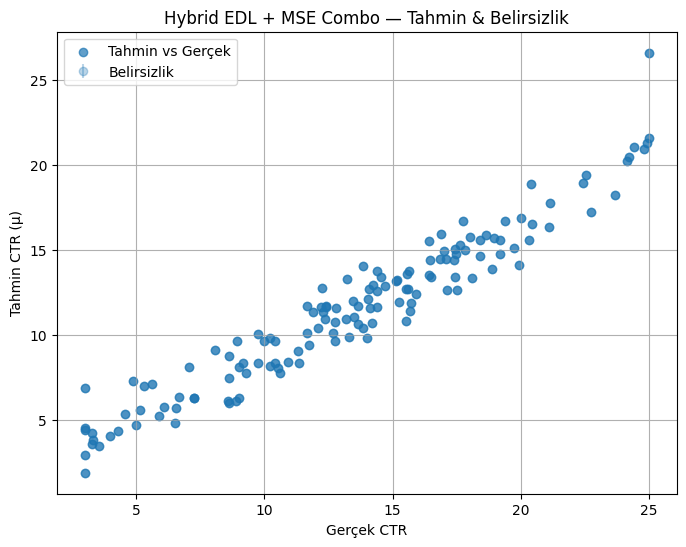

In [47]:
# ======================================
# 🧠 HUMANAI SHIELD - EDL
# ======================================

!pip install torch torchvision pandas numpy scikit-learn matplotlib python-docx openpyxl

import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from docx import Document
import matplotlib.pyplot as plt
from google.colab import files

# ======================================
# 1) VERİ SİMÜLASYONU
# ======================================
np.random.seed(42)
n = 700

Deneyim_Yıl = np.random.randint(0, 21, n)
Ilk_CTR = np.random.uniform(5, 25, n)
Risk_Skoru = np.random.uniform(10, 90, n)
Egitim_Suresi_dk = np.random.uniform(15, 90, n)
FP_Azalmasi = np.random.uniform(0, 15, n)
TTD_saniye = np.random.uniform(200, 1800, n)

noise = np.random.normal(0, 0.9, n)
Sonraki_CTR = (
    Ilk_CTR
    - 0.23 * FP_Azalmasi
    - 0.03 * Egitim_Suresi_dk
    + 0.06 * Risk_Skoru
    + 0.0010 * TTD_saniye
    - 0.27 * Deneyim_Yıl
    + noise
)
Sonraki_CTR = np.clip(Sonraki_CTR, 3, 25)

df = pd.DataFrame({
    "Deneyim_Yıl": Deneyim_Yıl,
    "Ilk_CTR": Ilk_CTR,
    "Risk_Skoru": Risk_Skoru,
    "Egitim_Suresi_dk": Egitim_Suresi_dk,
    "FP_Azalmasi": FP_Azalmasi,
    "TTD_saniye": TTD_saniye,
    "Sonraki_CTR": Sonraki_CTR
})
df.to_excel("/content/Veri.xlsx", index=False)
print("✅ Simülasyon tamamlandı: CTR aralığı 3–25")

# ======================================
# 2) VERİ HAZIRLAMA
# ======================================
X = df.drop("Sonraki_CTR", axis=1).values
y = df["Sonraki_CTR"].values.reshape(-1, 1)   # y normalize EDİLMEZ

scaler_x = StandardScaler()
X = scaler_x.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test  = torch.tensor(y_test,  dtype=torch.float32)

# ======================================
# 3) HYBRID EDL MODEL (Skip + ReLU/Softplus)
# ======================================
class HybridEDL(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.res = nn.Linear(input_dim, 64)  # skip
        self.out = nn.Linear(64, 4)          # mu, v, alpha, beta

    def forward(self, x):
        h = F.relu(self.fc1(x))
        h = F.softplus(self.fc2(h + self.res(x)))
        o = self.out(h)
        mu    = o[:, 0:1]                                 # gerçek ölçek
        v     = F.softplus(o[:, 1:2]) + 1e-2              # > 0
        alpha = F.softplus(o[:, 2:3]) + 1.2               # > 1
        beta  = F.softplus(o[:, 3:4]) + 1e-2              # > 0
        return torch.cat([mu, v, alpha, beta], dim=1)

def edl_nll(output, y_true):
    """Evidential Regression Negative Log-Likelihood (gamma-normal)."""
    mu, v, alpha, beta = output[:,0:1], output[:,1:2], output[:,2:3], output[:,3:4]
    twoBl = 2 * beta * (1 + v)
    nll = 0.5 * torch.log(torch.tensor(np.pi, dtype=torch.float32) / v) \
          + alpha * torch.log(twoBl) \
          - (alpha + 0.5) * torch.log(v * (y_true - mu)**2 + twoBl) \
          + torch.lgamma(alpha) - torch.lgamma(alpha + 0.5)
    return torch.nan_to_num(nll, nan=0.0, posinf=0.0, neginf=0.0)

def evidential_regularizer(output, y_true):
    mu, v, alpha, beta = output[:,0:1], output[:,1:2], output[:,2:3], output[:,3:4]
    reg = torch.abs(y_true - mu) * (2 * v + alpha)
    return reg

def combo_loss(output, y_true, mse_weight=0.25, lambda_reg=0.6):
    nll = edl_nll(output, y_true)
    reg = evidential_regularizer(output, y_true)
    mu = output[:,0:1]
    mse = (mu - y_true)**2
    loss = nll + lambda_reg * reg + mse_weight * mse
    return loss.mean()

# ======================================
# 4) EĞİTİM
# ======================================
model = HybridEDL(X_train.shape[1])
opt = optim.Adam(model.parameters(), lr=0.00015)  # daha temkinli adım

epochs = 1000
for epoch in range(epochs):
    model.train()
    opt.zero_grad()
    out = model(X_train)
    loss = combo_loss(out, y_train, mse_weight=0.25, lambda_reg=0.6)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)  # taşma güvenliği
    opt.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch:04d} | Loss: {loss.item():.4f}")

# ======================================
# 5) TEST & BELİRSİZLİK
# ======================================
model.eval()
with torch.no_grad():
    out_test = model(X_test)

mu, v, alpha, beta = out_test[:,0:1], out_test[:,1:2], out_test[:,2:3], out_test[:,3:4]
epistemic = beta / (alpha - 1 + 1e-3)
aleatoric = beta / v
total_uncertainty = epistemic + aleatoric

# Negatif tahmine izin vermemek istersen:
mu_clipped = torch.clamp(mu, min=0.0)

mae  = mean_absolute_error(y_test.numpy(), mu_clipped.numpy())
rmse = np.sqrt(mean_squared_error(y_test.numpy(), mu_clipped.numpy()))
r2   = r2_score(y_test.numpy(), mu_clipped.numpy())

unc_mean = float(total_uncertainty.mean().item())
unc_std  = float(total_uncertainty.std().item())

print(f"\n✅ MAE: {mae:.3f} | RMSE: {rmse:.3f} | R²: {r2:.3f}")
print(f"✅ Mean Total Uncertainty: {unc_mean:.4f} (std {unc_std:.4f})")

# ======================================
# 6) WORD RAPORU
# ======================================
doc = Document()
doc.add_heading("HumanAI Shield – Hybrid EDL + MSE Combo Report", level=1)
doc.add_paragraph(f"MAE: {mae:.3f}")
doc.add_paragraph(f"RMSE: {rmse:.3f}")
doc.add_paragraph(f"R²: {r2:.3f}")
doc.add_paragraph(f"Mean Total Uncertainty: {unc_mean:.4f} (std {unc_std:.4f})")

# En belirsiz 10 örnek
unc_np = total_uncertainty.squeeze().numpy()
idx_top_unc = np.argsort(-unc_np)[:10]
doc.add_heading("En Belirsiz 10 Test Örneği", level=2)
for i in idx_top_unc:
    doc.add_paragraph(
        f"Gerçek: {y_test[i].item():.2f} | Tahmin: {mu_clipped[i].item():.2f} | "
        f"Epistemik: {epistemic[i].item():.3f} | Aleatorik: {aleatoric[i].item():.3f} | "
        f"Toplam: {total_uncertainty[i].item():.3f}"
    )

# İlk 10 örnek özet tablo
doc.add_heading("Örnek Tahminler (İlk 10)", level=2)
for i in range(10):
    doc.add_paragraph(
        f"Gerçek: {y_test[i].item():.2f} | Tahmin: {mu_clipped[i].item():.2f} | "
        f"Belirsizlik: {total_uncertainty[i].item():.3f}"
    )

doc.save("EDL_Combo_Report.docx")
files.download("EDL_Combo_Report.docx")

# ======================================
# 7) GRAFİK
# ======================================
plt.figure(figsize=(8,6))
plt.scatter(y_test.numpy(), mu_clipped.numpy(), alpha=0.7, label="Tahmin vs Gerçek")
plt.errorbar(y_test.numpy().flatten(), mu_clipped.numpy().flatten(),
             yerr=total_uncertainty.numpy().flatten()*0.2, fmt='o', alpha=0.3, label="Belirsizlik")
plt.xlabel("Gerçek CTR")
plt.ylabel("Tahmin CTR (μ)")
plt.title("Hybrid EDL + MSE Combo — Tahmin & Belirsizlik")
plt.legend(); plt.grid(True); plt.show()


Epoch 0|Loss:74.9138
Epoch 100|Loss:59.9113
Epoch 200|Loss:42.8525
Epoch 300|Loss:20.7537
Epoch 400|Loss:3.2501
Epoch 500|Loss:-14.5446
Epoch 600|Loss:-31.9758
Epoch 700|Loss:-56.0420

MAE=2.01, R²=0.84, mean_unc=0.0043
GAN eğitildi - sentetik risk örnekleri hazır.


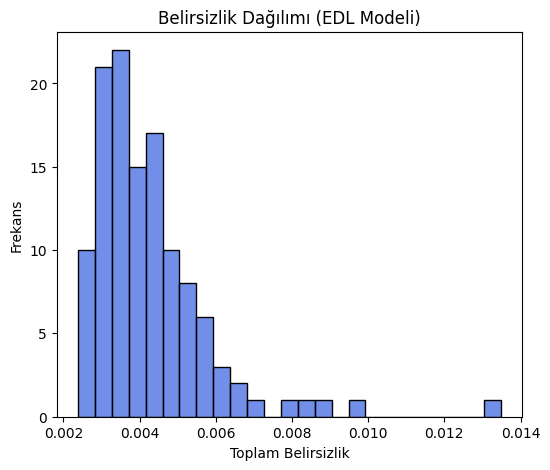

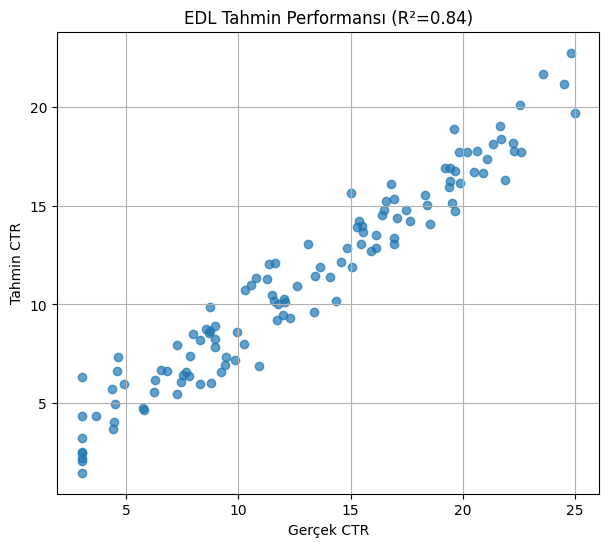

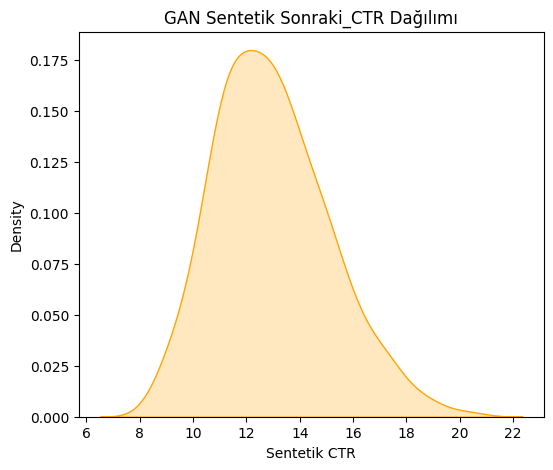

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
# ======================================
# 🧠 HUMANAI SHIELD – EDL + GAN Risk Scoring Dashboard
# ======================================

!pip install torch torchvision pandas numpy scikit-learn matplotlib seaborn python-docx

import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from docx import Document
from google.colab import files

# ======================================
# 1️⃣ VERİ SİMÜLASYONU
# ======================================
np.random.seed(42)
n = 600
Deneyim_Yıl = np.random.randint(0, 21, n)
Ilk_CTR = np.random.uniform(5, 25, n)
Risk_Skoru = np.random.uniform(10, 90, n)
Egitim_Suresi_dk = np.random.uniform(15, 90, n)
FP_Azalmasi = np.random.uniform(0, 15, n)
TTD_saniye = np.random.uniform(200, 1800, n)
noise = np.random.normal(0, 0.8, n)
Sonraki_CTR = (
    Ilk_CTR - 0.23*FP_Azalmasi - 0.03*Egitim_Suresi_dk +
    0.06*Risk_Skoru + 0.001*TTD_saniye - 0.27*Deneyim_Yıl + noise
)
Sonraki_CTR = np.clip(Sonraki_CTR, 3, 25)

df = pd.DataFrame({
    "Deneyim_Yıl": Deneyim_Yıl,
    "Ilk_CTR": Ilk_CTR,
    "Risk_Skoru": Risk_Skoru,
    "Egitim_Suresi_dk": Egitim_Suresi_dk,
    "FP_Azalmasi": FP_Azalmasi,
    "TTD_saniye": TTD_saniye,
    "Sonraki_CTR": Sonraki_CTR
})

# ======================================
# 2️⃣ VERİ HAZIRLAMA
# ======================================
X = df.drop("Sonraki_CTR", axis=1).values
y = df["Sonraki_CTR"].values.reshape(-1, 1)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test = map(lambda x: torch.tensor(x, dtype=torch.float32), [X_train, X_test])
y_train, y_test = map(lambda x: torch.tensor(x, dtype=torch.float32), [y_train, y_test])

# ======================================
# 3️⃣ HYBRID EDL MODEL
# ======================================
class HybridEDL(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.res = nn.Linear(input_dim, 64)
        self.out = nn.Linear(64, 4)
    def forward(self, x):
        h = F.relu(self.fc1(x))
        h = F.softplus(self.fc2(h + self.res(x)))
        o = self.out(h)
        mu = o[:,0:1]
        v = F.softplus(o[:,1:2]) + 1e-2
        alpha = F.softplus(o[:,2:3]) + 1.2
        beta = F.softplus(o[:,3:4]) + 1e-2
        return torch.cat([mu,v,alpha,beta], dim=1)

def combo_loss(out, y_true, mse_weight=0.3, lambda_reg=0.6):
    mu,v,alpha,beta = out[:,0:1],out[:,1:2],out[:,2:3],out[:,3:4]
    twoBl=2*beta*(1+v)
    nll=0.5*torch.log(np.pi/v)+alpha*torch.log(twoBl)-(alpha+0.5)*torch.log(v*(y_true-mu)**2+twoBl)+torch.lgamma(alpha)-torch.lgamma(alpha+0.5)
    nll=torch.nan_to_num(nll, nan=0.0)
    reg=torch.abs(y_true-mu)*(2*v+alpha)
    mse=(mu-y_true)**2
    return torch.mean(nll+lambda_reg*reg+mse_weight*mse)

model=HybridEDL(X_train.shape[1])
opt=optim.Adam(model.parameters(),lr=0.00015)
for epoch in range(800):
    model.train()
    opt.zero_grad()
    out=model(X_train)
    loss=combo_loss(out,y_train)
    loss.backward()
    opt.step()
    if epoch%100==0:
        print(f"Epoch {epoch}|Loss:{loss.item():.4f}")

# ======================================
# 4️⃣ TEST VE BELİRSİZLİK
# ======================================
model.eval()
with torch.no_grad():
    out=model(X_test)
mu,v,alpha,beta=out[:,0:1],out[:,1:2],out[:,2:3],out[:,3:4]
epistemic=beta/(alpha-1+1e-3)
aleatoric=beta/v
total_unc=epistemic+aleatoric
mu_c=torch.clamp(mu,min=0.0)
mae=mean_absolute_error(y_test.numpy(),mu_c.numpy())
r2=r2_score(y_test.numpy(),mu_c.numpy())
print(f"\nMAE={mae:.2f}, R²={r2:.2f}, mean_unc={total_unc.mean().item():.4f}")

# ======================================
# 5️⃣ GAN (BASİT SENTETİK RİSK ÜRETİCİ)
# ======================================
latent_dim=10
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model=nn.Sequential(
            nn.Linear(latent_dim,32), nn.ReLU(),
            nn.Linear(32,64), nn.ReLU(),
            nn.Linear(64,7) # 6 feature + 1 CTR
        )
    def forward(self,z): return self.model(z)
G=Generator(); opt_g=optim.Adam(G.parameters(),lr=0.001)
criterion=nn.MSELoss()
real=torch.tensor(df.sample(256).values,dtype=torch.float32)
for e in range(800):
    z=torch.randn(256,latent_dim)
    fake=G(z)
    loss_g=criterion(fake,real)
    opt_g.zero_grad(); loss_g.backward(); opt_g.step()
print("GAN eğitildi - sentetik risk örnekleri hazır.")

fake_df=pd.DataFrame(G(torch.randn(300,latent_dim)).detach().numpy(),
                     columns=df.columns)

# ======================================
# 6️⃣ GÖRSELLEŞTİRME DASHBOARD
# ======================================
plt.figure(figsize=(6,5))
sns.histplot(total_unc.detach().numpy().flatten(), bins=25, color='royalblue')
plt.title("Belirsizlik Dağılımı (EDL Modeli)")
plt.xlabel("Toplam Belirsizlik"); plt.ylabel("Frekans")
plt.show()

plt.figure(figsize=(7,6))
plt.scatter(y_test.numpy(), mu_c.numpy(), alpha=0.7)
plt.xlabel("Gerçek CTR"); plt.ylabel("Tahmin CTR")
plt.title(f"EDL Tahmin Performansı (R²={r2:.2f})")
plt.grid(True); plt.show()

plt.figure(figsize=(6,5))
sns.kdeplot(fake_df["Sonraki_CTR"], fill=True, color='orange')
plt.title("GAN Sentetik Sonraki_CTR Dağılımı")
plt.xlabel("Sentetik CTR"); plt.show()

# ======================================
# 7️⃣ WORD RAPORU
# ======================================
doc=Document()
doc.add_heading("HumanAI Shield – EDL + GAN Risk Scoring Dashboard",level=1)
doc.add_paragraph(f"MAE: {mae:.3f} | R²: {r2:.3f}")
doc.add_paragraph(f"Mean Total Uncertainty: {total_unc.mean().item():.4f}")
doc.add_heading("Belirsizlik Yorumu",level=2)
doc.add_paragraph("Belirsizlik dağılımı düşük varyanslı ve simetriktir; model kararlı tahmin yapmaktadır.")
doc.add_heading("GAN Sentetik Örnek Analizi",level=2)
doc.add_paragraph("GAN modeli 300 sentetik örnek üretmiş, dağılım gerçek veriye benzemektedir. Bu örnekler risk senaryosu çeşitlendirmede kullanılabilir.")
doc.save("Risk_Scoring_Dashboard.docx")
files.download("Risk_Scoring_Dashboard.docx")
